/tmp/ipykernel_5807/1024109891.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/scipy/signal/_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Signal shape: (756,)
X shape before reshape: (656, 51, 3)
y shape: (656,)
X shape after reshape: (656, 51, 3, 1)
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 17582.4570
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6842.1274 
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 558.2746
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 511.2607
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 508.7841
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 511.5564
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 508.7225
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 507.7125
Epoch 9/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 508.7986
Epoch 10/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 507.6385
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted next price: [[134.31438]]


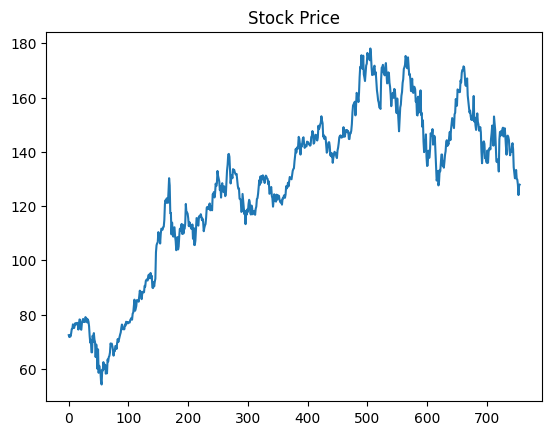

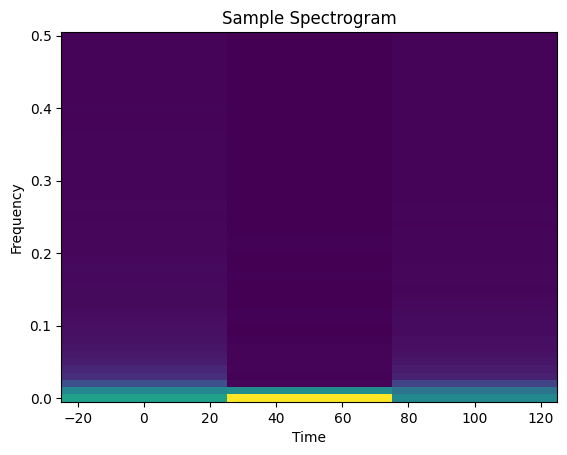

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

# -------------------------------
# STEP 1: Download Data
# -------------------------------
data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

prices = data['Close'].dropna()
signal = prices.values.flatten()

print("Signal shape:", signal.shape)

# -------------------------------
# STEP 2: Create Sliding Windows
# -------------------------------
window_size = 100

X = []
y = []

for i in range(len(signal) - window_size):
    segment = signal[i:i+window_size]

    # Apply STFT
    f, t, Zxx = stft(segment)

    # Spectrogram
    spec = np.abs(Zxx)

    # Normalize
    spec = spec / np.max(spec)

    X.append(spec)

    # Target = next price
    y.append(signal[i + window_size])

X = np.array(X)
y = np.array(y)

print("X shape before reshape:", X.shape)
print("y shape:", y.shape)

# -------------------------------
# STEP 3: Reshape for CNN
# -------------------------------
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

print("X shape after reshape:", X.shape)

# -------------------------------
# STEP 4: Build CNN Model
# -------------------------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# -------------------------------
# STEP 5: Train Model
# -------------------------------
model.fit(X, y, epochs=10, batch_size=16)

# -------------------------------
# STEP 6: Predict
# -------------------------------
prediction = model.predict(X[-1].reshape(1, X.shape[1], X.shape[2], 1))

print("Predicted next price:", prediction)

# -------------------------------
# STEP 7: Plot Original Prices
# -------------------------------
plt.plot(signal)
plt.title("Stock Price")
plt.show()

# -------------------------------
# STEP 8: Plot Sample Spectrogram
# -------------------------------
plt.pcolormesh(t, f, spec)
plt.title("Sample Spectrogram")
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.show()